# 06 Transfer learning — InceptionV3

Zamrznuta ImageNet baza + nova dense glava, na istoj fiksiranoj podeli kao custom modeli.

Ulaz je **299×299** (nativno za InceptionV3), a feature-i zamrznute baze se **kesiraju**
jednom na disk, pa se glava trenira nad 2048-dim vektorima.

Kernel: **venv sa TensorFlow-om**.

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path("..").resolve()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))

import tensorflow as tf
print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

I0000 00:00:1787139843.726059   50327 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787139843.768490   50327 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787139845.188894   50327 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Brza provera lanca

Malo slika po klasi, par epoha — samo da se vidi da kesiranje, oblici i labele rade.
Pise u zaseban folder, da ne pokvari pravi eksperiment.

In [2]:
!python src/transfer.py --exp-dir experiments/_smoke_transfer --limit 180 --epochs 3

I0000 00:00:1787139846.340652   50394 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1787139846.383540   50394 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787139847.189768   50394 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1787139847.921012   50394 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1766 MB memory:  -> device: 0, name: NVIDIA RTX A500 Laptop GPU, pci bus id: 0000:03:00.0, compute capability: 8.6


Found 180 validated image filenames belonging to 18 classes.
[train] 180 slika, 12 koraka


...

1/3 [=========>....................] - ETA: 2s - loss: 3.2735 - accuracy: 0.0625


Epoch 1: val_accuracy improved from -inf to 0.08889, saving model to /home/matejastojanovic/renaissance-to-pop-art-study/experiments/_smoke_transfer/head_best.keras
3/3 [==============================] - 1s 62ms/step - loss: 3.3037 - accuracy: 0.0556 - val_loss: 2.9506 - val_accuracy: 0.0889


Epoch 2/3
1/3 [=========>....................] - ETA: 0s - loss: 3.0057 - accuracy: 0.0938
Epoch 2: val_accuracy did not improve from 0.08889
3/3 [==============================] - 0s 14ms/step - loss: 3.0360 - accuracy: 0.0833 - val_loss: 2.8729 - val_accuracy: 0.0778
Epoch 3/3
1/3 [=========>....................] - ETA: 0s - loss: 2.9178 - accuracy: 0.0781


Epoch 3: val_accuracy improved from 0.08889 to 0.13333, saving model to /home/matejastojanovic/renaissance-to-pop-art-study/experiments/_smoke_transfer/head_best.keras
3/3 [==============================] - 0s 23ms/step - loss: 2.6990 - accuracy: 0.1278 - val_loss: 2.7693 - val_accuracy: 0.1333



najbolji val_accuracy: 0.1333
pun model: /home/matejastojanovic/renaissance-to-pop-art-study/experiments/_smoke_transfer/best.keras
run_config: /home/matejastojanovic/renaissance-to-pop-art-study/experiments/_smoke_transfer/run_config.json


## Kesiranje feature-a

Jednokratno, nad celim skupom. Na CPU-u traje dugo (18k slika kroz InceptionV3).

In [3]:
!python src/transfer.py --stage cache

I0000 00:00:1787139866.825837   50799 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1787139866.860962   50799 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787139867.609890   50799 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


kes vec postoji, preskacem (--recompute da se prepise)


## Trening dense glave

Nad keširanim feature-ima — sekunde po epohi, pa je 100 epoha jeftino.
Cuva se najbolja po `val_accuracy`, a zatim se sklapa pun model slika → softmax.

In [4]:
!python src/transfer.py --stage dense --epochs 100

I0000 00:00:1787139868.827880   50838 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787139868.860912   50838 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787139869.657780   50838 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


train: (12626, 2048) val: (2706, 2048)


I0000 00:00:1787139870.998261   50838 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1766 MB memory:  -> device: 0, name: NVIDIA RTX A500 Laptop GPU, pci bus id: 0000:03:00.0, compute capability: 8.6


Epoch 1/100


...

179/198 [==========================>...] - ETA: 0s - loss: 1.4553 - accuracy: 0.5144

187/198 [===========================>..] - ETA: 0s - loss: 1.4591 - accuracy: 0.5124

194/198 [============================>.] - ETA: 0s - loss: 1.4621 - accuracy: 0.5112


Epoch 100: val_accuracy did not improve from 0.52772
198/198 [==============================] - 2s 8ms/step - loss: 1.4655 - accuracy: 0.5104 - val_loss: 1.4476 - val_accuracy: 0.5148



najbolji val_accuracy: 0.5277
pun model: /home/matejastojanovic/renaissance-to-pop-art-study/experiments/transfer_dense/best.keras
run_config: /home/matejastojanovic/renaissance-to-pop-art-study/experiments/transfer_dense/run_config.json


In [5]:
!python src/plot_curves.py --model transfer_dense

sacuvano: /home/matejastojanovic/renaissance-to-pop-art-study/experiments/transfer_dense/curves.png
sacuvano: /home/matejastojanovic/renaissance-to-pop-art-study/reports/figures/transfer_dense_curves.png


## Evaluacija na test skupu

Pokrece se **tek na kraju**, nad `best.keras`.

In [6]:
!python src/evaluate.py --model transfer_dense --exp-dir experiments/transfer_dense

I0000 00:00:1787140035.843080   53534 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1787140035.886338   53534 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787140036.750240   53534 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Found 12626 validated image filenames belonging to 18 classes.


Found 2706 validated image filenames belonging to 18 classes.
Found 2706 validated image filenames belonging to 18 classes.


...

82/85 [===========================>..] - ETA: 0s

83/85 [============================>.] - ETA: 0s

84/85 [============================>.] - ETA: 0s

85/85 [==============================] - 14s 158ms/step



                         precision    recall  f1-score   support

01_Byzantin_Iconography       0.89      0.85      0.87       127
   02_Early_Renaissance       0.59      0.67      0.62       112
03_Northern_Renaissance       0.52      0.63      0.57       123
    04_High_Renaissance       0.50      0.60      0.55       125
             05_Baroque       0.46      0.29      0.36       148
              06_Rococo       0.43      0.55      0.48       125
         07_Romanticism       0.35      0.31      0.33       134
             08_Realism       0.45      0.34      0.39       180
       09_Impressionism       0.39      0.66      0.49       189
  10_Post_Impressionism       0.35      0.23      0.28       192
       11_Expressionism       0.35      0.29      0.32       154
           12_Symbolism       0.48      0.47      0.47       159
             13_Fauvism       0.37      0.43      0.40       108
              14_Cubism       0.59      0.70      0.64       184
          15_Surrealism

run config: {'model': 'transfer_dense', 'num_classes': 18, 'image_size': 299, 'batch_size': 64, 'epochs': 100, 'lr': 0.001, 'dropout': 0.5, 'params': 21839666, 'trainable_params': 36882, 'cached_features': True, 'augmentation': False}
test metrics: {'model': 'transfer_dense', 'weights': 'experiments/transfer_dense/best.keras', 'image_size': 299, 'params': 21839666, 'test_accuracy': 0.49889135360717773, 'test_loss': 1.4697766304016113, 'macro_f1': 0.49621886139430277, 'weighted_f1': 0.49090168374639087, 'num_test_images': 2706}


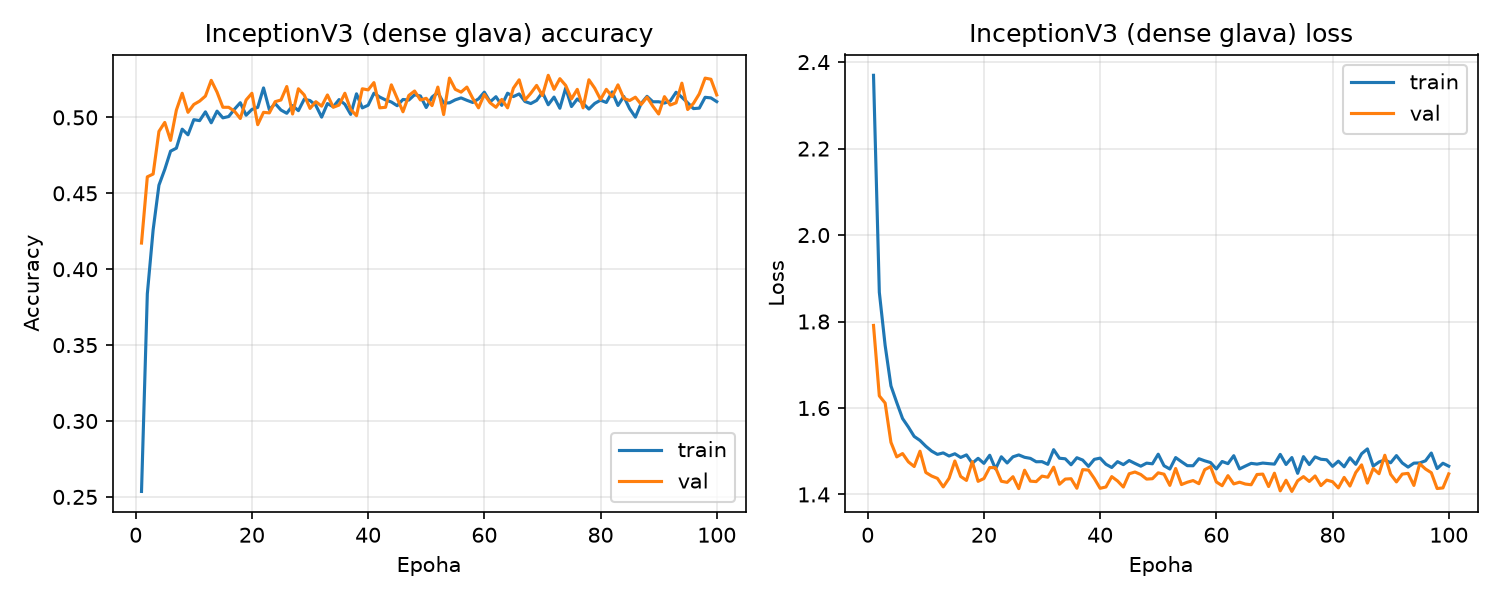

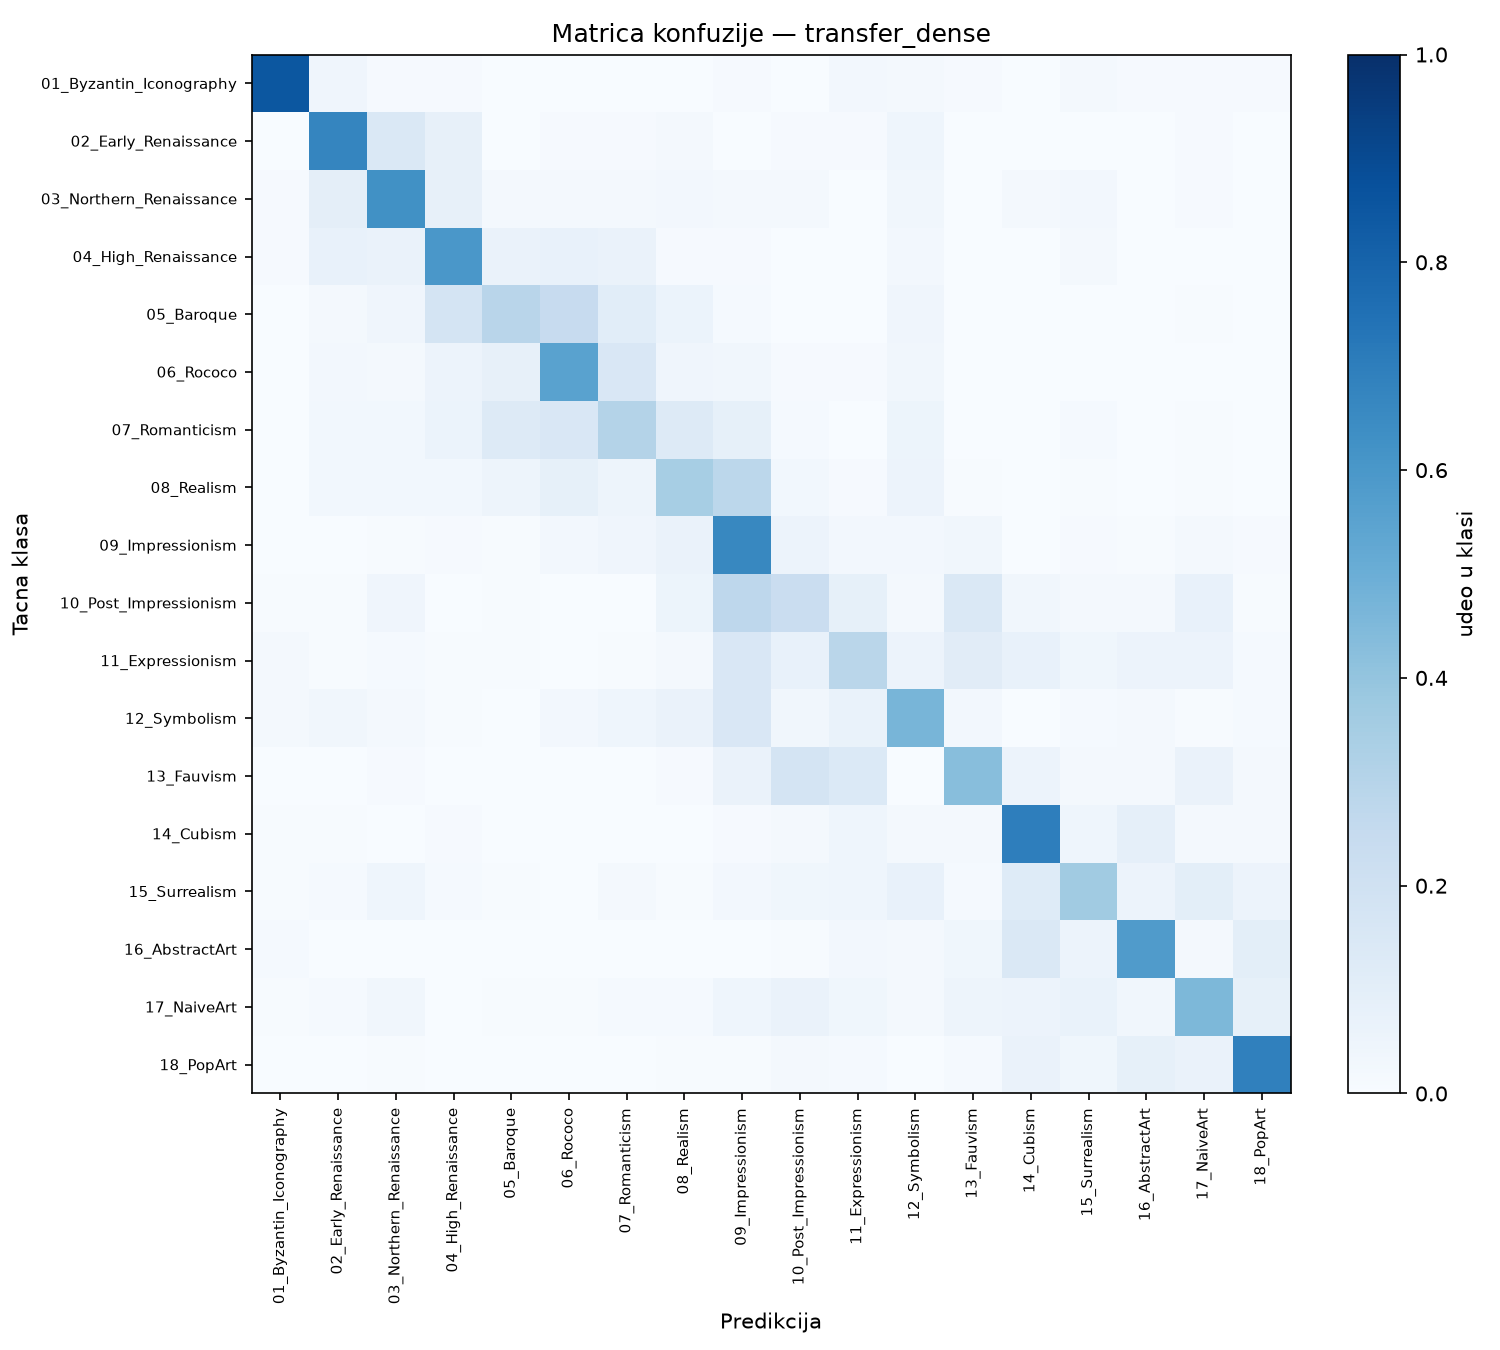

In [7]:
import json
from IPython.display import Image, display

with open("experiments/transfer_dense/run_config.json") as f:
    print("run config:", json.load(f))

with open("experiments/transfer_dense/test_metrics.json") as f:
    print("test metrics:", json.load(f))

display(Image("reports/figures/transfer_dense_curves.png"))
display(Image("reports/figures/transfer_dense_confusion.png"))

## Poredjenje sa custom modelima

Slucajno pogadjanje za 18 klasa je **5.56%**. Referentne vrednosti iz rada:
VGG-lite ~31%, hibrid ~36%, transfer learning ~56-57%.

In [8]:
import json
from pathlib import Path

import pandas as pd

rows = []
for name, exp in (
    ("VGG-lite", "experiments/custom_vgglite"),
    ("Hibrid", "experiments/custom_hybrid"),
    ("InceptionV3 (dense)", "experiments/transfer_dense"),
):
    metrics_path = Path(exp) / "test_metrics.json"
    if not metrics_path.is_file():
        continue
    with open(metrics_path) as f:
        m = json.load(f)
    rows.append({
        "model": name,
        "params": m.get("params"),
        "test accuracy": m.get("test_accuracy"),
        "macro F1": m.get("macro_f1"),
    })

pd.DataFrame(rows)

,model,params,test accuracy,macro F1
0,VGG-lite,NaN,0.351441,NaN
1,InceptionV3 (dense),21839666.0,0.498891,0.496219
